# Part 3 – Advanced Modeling: Ensembles, Tuning, and Full ML Pipeline

## Objective

The objective of this part is to build, evaluate, and compare advanced machine learning models for the house price classification problem. This includes training Decision Tree, Random Forest, and Gradient Boosting models, performing hyperparameter tuning and cross-validation, analyzing feature importance, and building a complete machine learning pipeline. The performance of each model is evaluated using appropriate classification metrics to identify the most robust and reliable model.

# Task 1: Decision Tree Baseline

## Objective

Train a Decision Tree Classifier using the default hyperparameters and evaluate its performance on both the training and testing datasets. Compare the training and testing accuracy to determine whether the model exhibits overfitting.

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
y_reg = df["SalePrice"]

In [4]:
X = df.drop("SalePrice", axis=1)

In [5]:
y_clf = (y_reg > y_reg.median()).astype(int)


## One-Hot Encoding

Convert all categorical features into numerical dummy variables so they can be used by machine learning algorithms.

In [6]:
# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after One-Hot Encoding:", X.shape)
X.head()

Shape after One-Hot Encoding: (1460, 245)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [7]:
print(X.shape)
print(X.select_dtypes(include=["object"]).columns)

(1460, 245)
Index([], dtype='object')


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [11]:
dt_model = DecisionTreeClassifier(random_state=42)

In [12]:
dt_model.fit(X_train_scaled, y_clf_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
train_pred = dt_model.predict(X_train_scaled)
test_pred = dt_model.predict(X_test_scaled)

In [14]:
train_accuracy = accuracy_score(y_clf_train, train_pred)

test_accuracy = accuracy_score(y_clf_test, test_pred)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy : 0.8732876712328768


### Observation

The Decision Tree classifier achieved 100% training accuracy and 87.33% testing accuracy.

This indicates that the model is overfitting the training data. Since the default Decision Tree grows without restrictions, it learns the training data too closely, including noise and outliers. As a result, it performs perfectly on the training set but slightly worse on unseen test data.

### Conclusion

The baseline Decision Tree achieved perfect training accuracy (100%) but a lower testing accuracy (87.33%). This indicates overfitting because the model has memorized the training data instead of learning general patterns. Decision Trees with default settings tend to grow very deep, making them high-variance models.

# Task 2 – Controlled Decision Tree

## Objective

Train a Decision Tree Classifier with controlled hyperparameters (max_depth=5 and min_samples_split=20) to reduce overfitting and compare its performance with the baseline Decision Tree.

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_controlled.fit(X_train_scaled, y_clf_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
train_pred_controlled = dt_controlled.predict(X_train_scaled)
test_pred_controlled = dt_controlled.predict(X_test_scaled)

In [17]:
train_accuracy_controlled = accuracy_score(y_clf_train, train_pred_controlled)

test_accuracy_controlled = accuracy_score(y_clf_test, test_pred_controlled)

print("Training Accuracy :", train_accuracy_controlled)
print("Testing Accuracy :", test_accuracy_controlled)

Training Accuracy : 0.9383561643835616
Testing Accuracy : 0.9041095890410958


### Observation

The Controlled Decision Tree achieved a training accuracy of *93.84%* and a testing accuracy of *90.41%*.

Compared to the baseline Decision Tree, the gap between training and testing accuracy has reduced. This indicates that overfitting has decreased and the model generalizes better to unseen data.

The max_depth parameter limits how deep the tree can grow, preventing it from learning unnecessary details. The min_samples_split parameter ensures that a node is split only when it contains at least 20 samples, reducing splits based on noise.

# Task 3 – Gini vs Entropy Comparison

## Objective

Compare Decision Tree classifiers using the Gini and Entropy splitting criteria and evaluate their test performance.

In [18]:
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_gini.fit(X_train_scaled, y_clf_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_entropy.fit(X_train_scaled, y_clf_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
gini_pred = dt_gini.predict(X_test_scaled)
entropy_pred = dt_entropy.predict(X_test_scaled)

In [21]:
gini_accuracy = accuracy_score(y_clf_test, gini_pred)
entropy_accuracy = accuracy_score(y_clf_test, entropy_pred)

print("Gini Test Accuracy :", gini_accuracy)
print("Entropy Test Accuracy :", entropy_accuracy)

Gini Test Accuracy : 0.8938356164383562
Entropy Test Accuracy : 0.9143835616438356


### Observation

Two Decision Tree models were trained using different splitting criteria: Gini and Entropy.

- Gini Test Accuracy: *89.38%*
- Entropy Test Accuracy: *91.44%*

The Entropy-based Decision Tree achieved slightly higher test accuracy than the Gini-based Decision Tree. This suggests that, for this dataset, the Entropy criterion produced slightly better splits and generalized better on unseen data.

# Task 4 – Random Forest Classifier

## Objective

Train a Random Forest Classifier, evaluate its performance using Accuracy and ROC-AUC, and identify the most important features contributing to the predictions.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_scaled, y_clf_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
train_pred_rf = rf_model.predict(X_train_scaled)
test_pred_rf = rf_model.predict(X_test_scaled)

In [25]:
train_accuracy_rf = accuracy_score(y_clf_train, train_pred_rf)

test_accuracy_rf = accuracy_score(y_clf_test, test_pred_rf)

roc_auc_rf = roc_auc_score(
    y_clf_test,
    rf_model.predict_proba(X_test_scaled)[:, 1]
)

print("Training Accuracy :", train_accuracy_rf)
print("Testing Accuracy :", test_accuracy_rf)
print("ROC-AUC :", roc_auc_rf)

Training Accuracy : 0.997431506849315
Testing Accuracy : 0.928082191780822
ROC-AUC : 0.9795927941452429


### Observation

The Random Forest classifier achieved a training accuracy of *99.74%, a testing accuracy of **92.81%, and a ROC-AUC score of **0.9796*.

Compared to the Decision Tree models, Random Forest achieved higher testing accuracy and an excellent ROC-AUC score. The ensemble of multiple decision trees helps reduce overfitting and improves the model's ability to generalize to unseen data.

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(5)

,Feature,Importance
16,GrLivArea,0.067951
6,YearBuilt,0.059878
19,FullBath,0.055129
4,OverallQual,0.054327
26,GarageCars,0.051691


 ### Observation

The Random Forest model identified the following as the five most important features:

1. GrLivArea
2. YearBuilt
3. FullBath
4. OverallQual
5. GarageCars

These features contribute the most toward distinguishing high-priced and low-priced houses in the classification model.

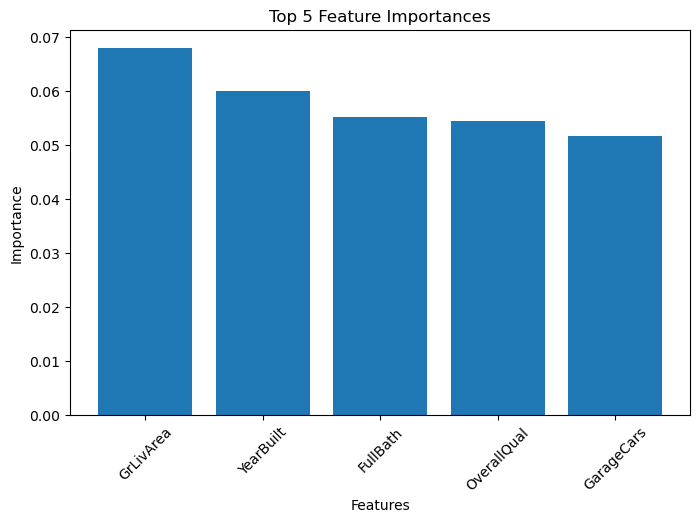

In [27]:
import matplotlib.pyplot as plt

top5 = feature_importance.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5["Feature"], top5["Importance"])
plt.title("Top 5 Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.savefig("../images/top5_feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [28]:
import os
print(os.getcwd())

C:\Users\ayaan\OneDrive\Documents\HousePrice_EDA_Project\HousePrice_Advanced modeling Part 3\notebooks


In [29]:
print(os.listdir())

['.ipynb_checkpoints', 'best_model.pkl', 'cleaned_data.csv', 'images.png', 'Part3_Advanced_Modeling.ipynb']


# Task 4a – Gradient Boosting Classifier

## Objective

Train a Gradient Boosting Classifier and evaluate its performance using training accuracy, testing accuracy, and ROC-AUC score. Compare its performance with the Decision Tree and Random Forest models to understand how boosting improves predictive performance.

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

In [31]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_scaled, y_clf_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [32]:
train_pred_gb = gb_model.predict(X_train_scaled)
test_pred_gb = gb_model.predict(X_test_scaled)

In [33]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [34]:
train_accuracy_gb = accuracy_score(y_clf_train, train_pred_gb)
test_accuracy_gb = accuracy_score(y_clf_test, test_pred_gb)

roc_auc_gb = roc_auc_score(
    y_clf_test,
    gb_model.predict_proba(X_test_scaled)[:, 1]
)

print("Training Accuracy :", train_accuracy_gb)
print("Testing Accuracy  :", test_accuracy_gb)
print("ROC-AUC           :", roc_auc_gb)

Training Accuracy : 0.9931506849315068
Testing Accuracy  : 0.934931506849315
ROC-AUC           : 0.981610058172265


### Observation

The Gradient Boosting Classifier achieved a training accuracy of *99.32%, a testing accuracy of **93.49%, and a ROC-AUC score of **0.9816*.

The model performed very well on the classification task, with a high ROC-AUC indicating excellent class discrimination. Gradient Boosting builds trees sequentially, where each new tree learns from the errors made by the previous trees, resulting in improved predictive performance and strong generalization on unseen data.

# Task 4b – Feature Ablation Study

## Objective

Identify the five least important features from the Random Forest model, remove them from the dataset, retrain the model using the same hyperparameters, and compare the ROC-AUC score with the original model to evaluate whether those features contribute meaningfully to prediction performance.

In [35]:
least5 = feature_importance.sort_values(
    by="Importance",
    ascending=True
).head(5)

least5

,Feature,Importance
91,Condition2_PosN,0.0
57,Neighborhood_BrDale,0.0
94,Condition2_RRNn,0.0
231,MiscFeature_TenC,0.0
140,Exterior2nd_Other,0.0


In [36]:
type(X_train_scaled)

numpy.ndarray

In [37]:
least_features = least5["Feature"].tolist()

X_reduced = X.drop(columns=least_features)

print(X_reduced.shape)

(1460, 240)


In [38]:
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

In [39]:
scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

In [40]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(X_train_reduced_scaled, y_train_reduced)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
reduced_pred = rf_reduced.predict(X_test_reduced_scaled)

In [43]:
reduced_auc = roc_auc_score(
    y_test_reduced,
    rf_reduced.predict_proba(X_test_reduced_scaled)[:, 1]
)

print("Original ROC-AUC :", roc_auc_rf)
print("Reduced ROC-AUC  :", reduced_auc)

Original ROC-AUC : 0.9795927941452429
Reduced ROC-AUC  : 0.9770125727153313


### Observation

The Random Forest model trained with all features achieved a ROC-AUC score of *0.9796, while the model trained after removing the five least important features achieved a ROC-AUC score of **0.9770*.

The reduction in ROC-AUC is very small, indicating that the removed features contributed little to the model's predictive performance. This suggests that these features were largely uninformative and could be removed without significantly affecting model accuracy. Removing such features can simplify the model, reduce computational cost, and make deployment more efficient while maintaining similar predictive performance.

# Task 5 – Cross-Validated Model Comparison

## Objective

Evaluate the performance of multiple classification models using 5-fold Stratified Cross-Validation with ROC-AUC as the evaluation metric. Compare the mean and standard deviation of ROC-AUC scores to determine which model generalizes best.

In [44]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression (Recreated for Cross-Validation)

The Logistic Regression model from Part 2 is recreated here so it can be included in the cross-validation comparison with the Decision Tree, Random Forest, and Gradient Boosting models.

In [46]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_clf_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_cv = cross_val_score(log_model, X_train_scaled, y_clf_train,
                         cv=cv, scoring="roc_auc")

dt_cv = cross_val_score(dt_controlled, X_train_scaled, y_clf_train,
                        cv=cv, scoring="roc_auc")

rf_cv = cross_val_score(rf_model, X_train_scaled, y_clf_train,
                        cv=cv, scoring="roc_auc")

gb_cv = cross_val_score(gb_model, X_train_scaled, y_clf_train,
                        cv=cv, scoring="roc_auc")

In [48]:
models = {
    "Logistic Regression": log_cv,
    "Decision Tree": dt_cv,
    "Random Forest": rf_cv,
    "Gradient Boosting": gb_cv
}

for name, scores in models.items():
    print(f"\n{name}")
    print(f"Mean ROC-AUC : {scores.mean():.4f}")
    print(f"Std ROC-AUC  : {scores.std():.4f}")


Logistic Regression
Mean ROC-AUC : 0.9514
Std ROC-AUC  : 0.0125

Decision Tree
Mean ROC-AUC : 0.9296
Std ROC-AUC  : 0.0107

Random Forest
Mean ROC-AUC : 0.9807
Std ROC-AUC  : 0.0056

Gradient Boosting
Mean ROC-AUC : 0.9787
Std ROC-AUC  : 0.0073


### Observation

- Random Forest achieved the highest mean ROC-AUC (0.9807) with the lowest standard deviation (0.0056), indicating the best and most stable performance across the 5 folds.
- Gradient Boosting performed similarly with a mean ROC-AUC of 0.9787 but was slightly less stable than Random Forest.
- Logistic Regression achieved a respectable mean ROC-AUC of 0.9514, serving as a strong baseline model.
- Decision Tree had the lowest mean ROC-AUC (0.9296), showing that a single tree generalizes less effectively than ensemble methods.
- Based on cross-validation performance, Random Forest is selected as the best model for further tuning.

# Task 6: Hyperparameter Tuning with GridSearchCV

## Objective

Tune the Random Forest classifier using GridSearchCV to identify the best combination of hyperparameters based on ROC-AUC score through 5-fold cross-validation.

In [49]:
#import required libraries

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [50]:
#parameter grid

param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5]
}

In [51]:
# Create pipeline

pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

In [52]:
#Stratified K- Fold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [53]:
#GridSearchCV

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [54]:
# Train

grid_search.fit(X_train, y_clf_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'randomforestclassifier__max_depth': [5, 10, ...], 'randomforestclassifier__min_samples_leaf': [1, 5], 'randomforestclassifier__n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [55]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}

Best ROC-AUC:
0.9812036387003792


## Observation

- GridSearchCV successfully evaluated multiple Random Forest hyperparameter combinations using 5-fold cross-validation.
- The best model was obtained with *n_estimators = 200, **max_depth = 10, and **min_samples_leaf = 1*.
- The optimized model achieved a *best cross-validated ROC-AUC score of 0.9812*, which is slightly higher than the default Random Forest model.
- A total of *18 hyperparameter combinations* were tested, resulting in *90 model fits* (18 combinations × 5 folds).
- The tuned Random Forest pipeline will be used as the final model for the remaining tasks.

# Task 7: Manual Learning Curve

## Objective

Train the best pipeline obtained from GridSearchCV on progressively larger subsets of the training data (20%, 40%, 60%, 80%, and 100%) and compare the training and test ROC-AUC scores to analyze the model's learning behavior.

In [56]:
import pandas as pd
from sklearn.metrics import roc_auc_score

In [57]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []

In [58]:
best_pipeline = grid_search.best_estimator_

for f in fractions:

    n = int(f * len(X_train))

    X_subset = X_train.iloc[:n]
    y_subset = y_clf_train.iloc[:n]

    best_pipeline.fit(X_subset, y_subset)

    train_auc = roc_auc_score(
        y_subset,
        best_pipeline.predict_proba(X_subset)[:,1]
    )

    test_auc = roc_auc_score(
        y_clf_test,
        best_pipeline.predict_proba(X_test)[:,1]
    )

    results.append([f, train_auc, test_auc])

In [59]:
learning_curve = pd.DataFrame(
    results,
    columns=[
        "Training Fraction",
        "Training AUC",
        "Test AUC"
    ]
)

learning_curve

,Training Fraction,Training AUC,Test AUC
0,0.2,1.000000,0.979640
1,0.4,1.000000,0.979546
2,0.6,1.000000,0.977857
3,0.8,0.999991,0.981329
4,1.0,0.999935,0.980625


In [60]:
learning_curve.to_csv(
    "../data/learning_curve.csv",
    index=False
)

## Observation

- The training AUC remained close to *1.0* across all training fractions, indicating that the Random Forest model fits the training data very well.
- The test AUC remained consistently high (around *0.98*) and showed a slight improvement as more training data was used before stabilizing.
- The stable performance between *80% and 100%* of the training data suggests that the model has largely reached its learning capacity.
- Since the test AUC plateaus at larger training sizes, collecting substantially more data is unlikely to produce significant performance improvements.
- Overall, the model demonstrates strong generalization with minimal overfitting and appears to be *capacity-limited rather than data-limited*.

# Task 8: Serialize the Best Model

## Objective

Save the best pipeline obtained from GridSearchCV as a .pkl file, reload it, and verify that it can successfully make predictions on new data.

In [61]:
import joblib

In [62]:
best_pipeline = grid_search.best_estimator_

joblib.dump(best_pipeline, "../best_model.pkl")

['../best_model.pkl']

In [63]:
joblib.dump(best_pipeline, "best_model.pkl")

['best_model.pkl']

In [64]:
loaded_model = joblib.load("../best_model.pkl")

In [65]:
sample_data = X_test.head(5)

predictions = loaded_model.predict(sample_data)

print("Predictions:")
print(predictions)

Predictions:
[0 0 0 1 1]


In [66]:
comparison = sample_data.copy()
comparison["Actual"] = y_clf_test.head(5).values
comparison["Predicted"] = predictions

comparison

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Actual,Predicted
395,396,20,68.0,9571,5,6,1956,1956,0.0,739,...,False,False,True,False,False,False,True,False,0,0
1085,1086,85,73.0,9069,6,6,1992,1992,0.0,747,...,False,False,True,False,False,False,True,False,0,0
570,571,90,74.0,13101,5,5,1965,1965,108.0,231,...,False,False,True,False,False,False,True,False,0,0
151,152,20,107.0,13891,8,5,2007,2008,436.0,1400,...,True,False,False,False,False,False,False,True,1,1
1354,1355,60,69.0,10316,7,5,2000,2000,0.0,735,...,False,False,True,False,False,False,True,False,1,1


In [67]:
comparison.tail()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Actual,Predicted
395,396,20,68.0,9571,5,6,1956,1956,0.0,739,...,False,False,True,False,False,False,True,False,0,0
1085,1086,85,73.0,9069,6,6,1992,1992,0.0,747,...,False,False,True,False,False,False,True,False,0,0
570,571,90,74.0,13101,5,5,1965,1965,108.0,231,...,False,False,True,False,False,False,True,False,0,0
151,152,20,107.0,13891,8,5,2007,2008,436.0,1400,...,True,False,False,False,False,False,False,True,1,1
1354,1355,60,69.0,10316,7,5,2000,2000,0.0,735,...,False,False,True,False,False,False,True,False,1,1


In [68]:
comparison[["Actual", "Predicted"]]

,Actual,Predicted
395,0,0
1085,0,0
570,0,0
151,1,1
1354,1,1


## Observation

- The best model was successfully saved using Joblib as best_model.pkl.
- The saved model was loaded successfully without any errors.
- Predictions generated by the loaded model matched the actual labels for the sample test data, confirming that the model serialization and deserialization process worked correctly.